## Preparation

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
PAL = {'navy': '#003f5c', 'blue': '#2f4b7c', 'purple':'#665191',
       'coral':'#f95d6a','orange':'#ff7c43', 'yellow':'#ffa600'}
FRONTLINE = ['Kharkiv Oblast', 'Donetsk Oblast', 'Sumy Oblast',
             'Zaporizhzhia Oblast', 'Kherson Oblast']
df_m = pd.read_csv('../data/processed/merged_dataset.csv')
df_m['datetime_hour'] = pd.to_datetime(df_m['datetime_hour'])

assert df_m.shape[0] > 100000, f"Dataset is too small: {df_m.shape[0]} rows"

main_cols = ['region', 'datetime_hour', 'alarm', 'hour_temp',
             'hour_visibility', 'hour_windspeed', 'hour_humidity', 'n_regions_alarm']

missing = [c for c in main_cols if c not in df_m.columns]
if missing:
    print(f"Missing columns: {missing}")

print(f"Dataset shape: {df_m.shape}")
print(f"Unique regions: {df_m['region'].nunique()}/24")
print(f"Timeframe: {df_m['datetime_hour'].min()} to {df_m['datetime_hour'].max()}")
print(f"Overall alarm rate: {df_m['alarm'].mean()*100:.2f}%")
nans = df_m[main_cols].isnull().sum()
nans = nans[nans > 0]

if len(nans) > 0:
    print(f"Found NaNs in main columns:\n{nans}")
else:
    print("No NaNs found in main columns")

print("Setup complete")

Dataset shape: (844417, 543)
Unique regions: 24/24
Timeframe: 2022-02-24 00:00:00 to 2026-03-16 23:00:00
Overall alarm rate: 20.66%
Found NaNs in main columns:
hour_visibility    91513
dtype: int64
Setup complete


## Conclusion to preparation part
During the review of the merged_dataset, we found 91513 missing values in the hour_visibility column. For EDA plots those rows were dropped to ensure the existing trend was displayed correctly. Since we had already noticed NaNs in visibility during the merge, we applied median imputation at the Feature Engineering stage. This way the binary flag low_visibility wouldnʼt distort the modeling results due to missing data.

## 1. WEATHER vs ALARMS

## Hypothesis 1
We hypothesize that meteorological conditions (such as visibility, cloud cover, and wind) significantly influence the frequency of air alarms in rear regions, assuming the enemy relies on specific weather windows for optimal drone and missile routing.

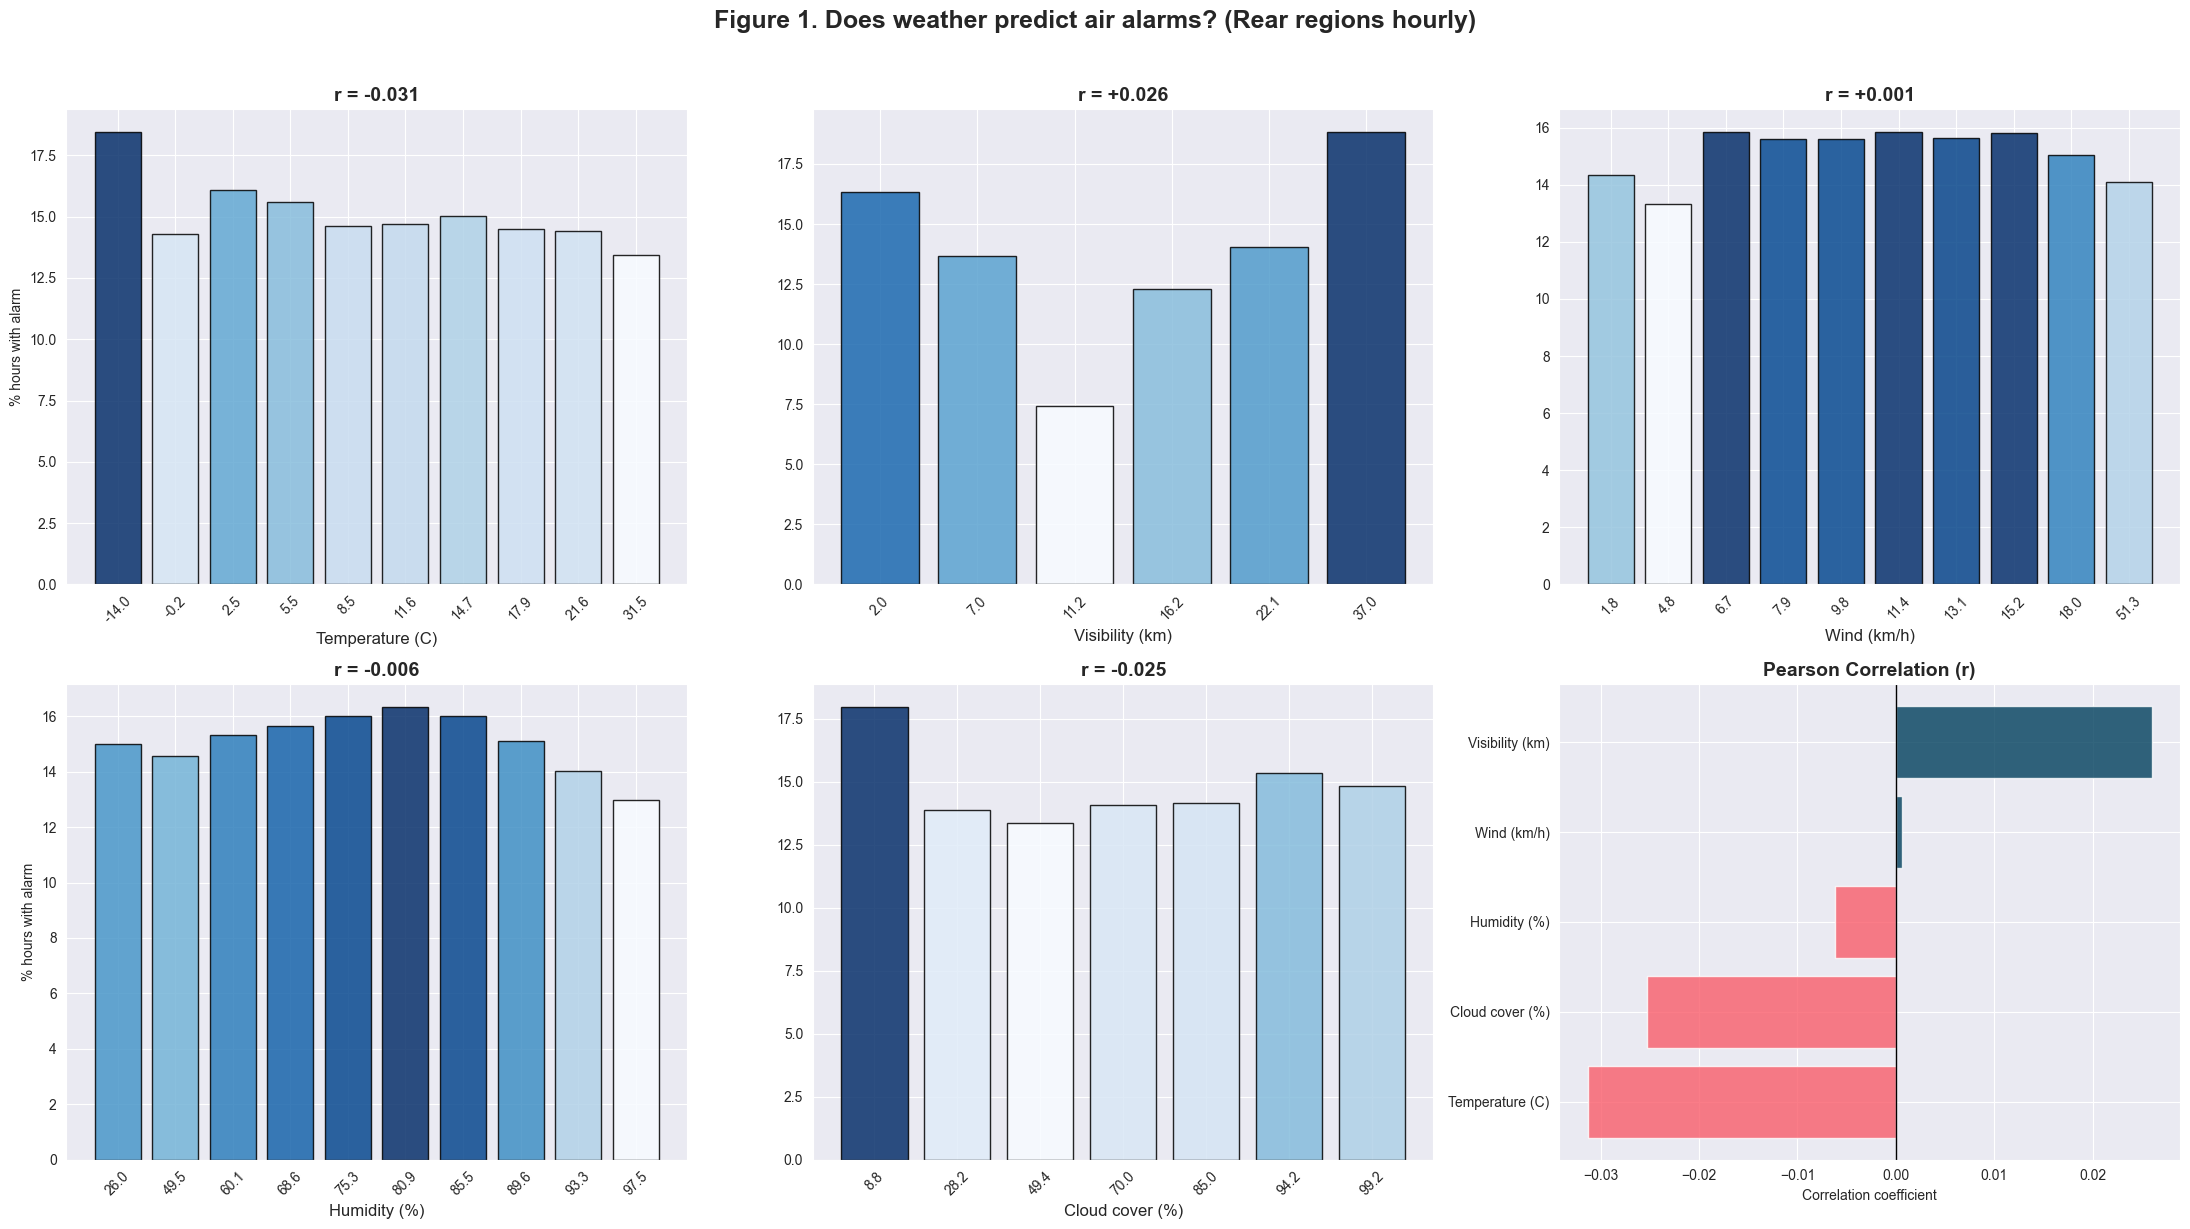

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
PAL = {'navy': '#003f5c', 'coral': '#f95d6a', 'blue': '#2f4b7c'}
FRONTLINE = ['Kharkiv Oblast', 'Donetsk Oblast', 'Sumy Oblast',
             'Zaporizhzhia Oblast', 'Kherson Oblast']
df_rear = df_m[~df_m['region'].isin(FRONTLINE)].copy()
parameters = [
    ('hour_temp', 'Temperature (C)'),
    ('hour_visibility', 'Visibility (km)'),
    ('hour_windspeed', 'Wind (km/h)'),
    ('hour_humidity', 'Humidity (%)'),
    ('hour_cloudcover', 'Cloud cover (%)')
]

fig, axes = plt.subplots(2, 3, figsize = (22, 12))
axes = axes.flatten()
correlations = {}
for idx, (parameter, label) in enumerate(parameters):
    ax = axes[idx]
    if parameter not in df_rear.columns:
        ax.set_title(f'{label} not found', color ='red')
        continue

    valid_data = df_rear.dropna(subset = [parameter, 'alarm'])
    if len(valid_data) == 0:
        continue
    r_val = valid_data[parameter].corr(valid_data['alarm'])
    correlations[label] = r_val
    bins = pd.qcut(valid_data[parameter], q = 10, duplicates ='drop')
    binned = valid_data.groupby(bins, observed=False)['alarm'].mean() * 100

    norm = plt.Normalize(binned.min(), binned.max())
    colors = plt.cm.Blues(norm(binned.values))

    bars = ax.bar(range(len(binned)), binned.values, color = colors, edgecolor = 'black', alpha = 0.85)

    ax.set_xticks(range(len(binned)))
    ax.set_xticklabels([f'{b.mid:.1f}' for b in binned.index], rotation = 45, fontsize = 10)

    ax.set_title(f"r = {r_val:+.3f}", fontweight = 'bold', fontsize = 14)
    ax.set_xlabel(label, fontsize = 12)
    ax.set_ylabel('% hours with alarm' if idx % 3 == 0 else '')
ax_summary = axes[5]
if correlations:
    corr_series = pd.Series(correlations).sort_values()
    colors_summary = [PAL['coral'] if val < 0 else PAL['navy'] for val in corr_series.values]

    ax_summary.barh(corr_series.index, corr_series.values, color = colors_summary, alpha = 0.8)
    ax_summary.set_title("Pearson Correlation (r)", fontweight='bold', fontsize = 14)
    ax_summary.set_xlabel("Correlation coefficient")
    ax_summary.axvline(0, color = 'black', linewidth = 1)

plt.suptitle('Figure 1. Does weather predict air alarms? (Rear regions hourly)',
             fontsize = 18, fontweight = 'bold', y = 1.02)
plt.tight_layout()
plt.savefig('plots/merged/M1_weather_vs_alarms.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## Conclusion (Figure 1)
The analysis of the weather parameters clearly demonstrates that meteorological conditions have almost no impact on the frequency of air alarms in the rear regions. The Pearson correlation coefficients across all variables are extremely weak, around zero (ranging from -0.031 to +0.026), which indicates a complete lack of linear relationship. Although visual inspection of the binned data shows very minor fluctuations, such as a slight localized peak in alarms during perfectly clear skies, these variations are negligible in the grand scheme of the dataset. This confirms that attacks on rear regions are dictated by the adversary's strategic planning and military schedules rather than daily weather patterns, meaning these meteorological features will likely have minimal predictive power in our final machine learning models.

## 2. CLASS IMBALANCE

## Hypothesis 2
We hypothesize that because air alarms are relatively rare events compared to continuous periods of calm, using standard accuracy to evaluate our predictive model will be misleading and mask the model's true inability to detect actual threats.

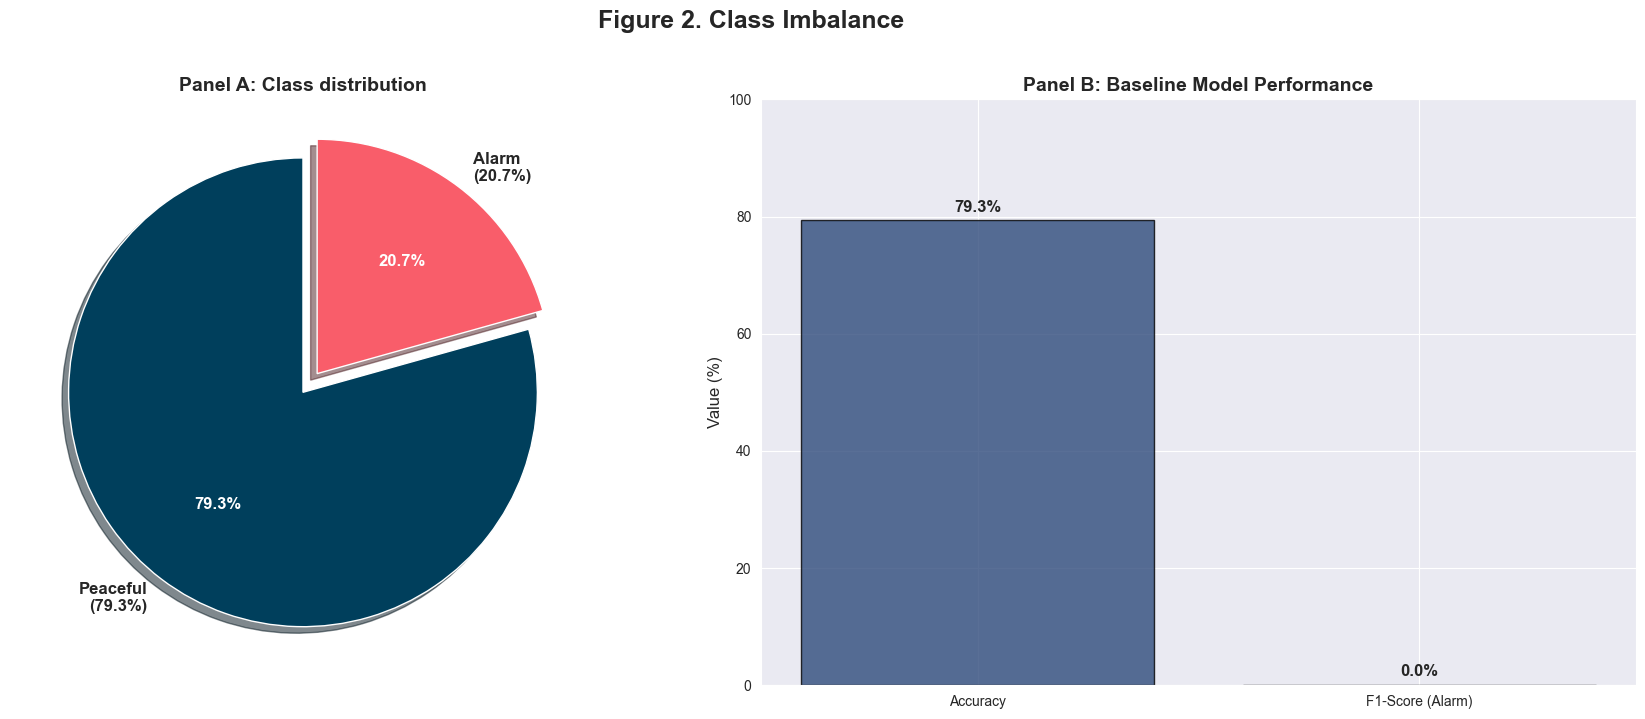

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
PAL = {'navy': '#003f5c', 'coral': '#f95d6a', 'blue': '#2f4b7c'}
class_counts = df_m['alarm'].value_counts()
total_count = len(df_m)
percentages = class_counts / total_count * 100
dummy_accuracy = percentages[0]
dummy_f1_alarm = 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

explode = (0, 0.1)
labels = [f"Peaceful\n({percentages[0]:.1f}%)", f"Alarm\n({percentages[1]:.1f}%)"]
colors = [PAL['navy'], PAL['coral']]

patches, texts, autotexts = ax1.pie(class_counts, labels = labels, autopct = '%1.1f%%', startangle = 90, colors = colors,
                                    explode = explode, shadow = True, textprops = {'fontsize': 12, 'fontweight': 'bold'})
for autotext in autotexts:
    autotext.set_color('white')

ax1.set_title("Panel A: Class distribution", fontsize = 14, fontweight = 'bold')

metrics_dummy = ['Accuracy', 'F1-Score (Alarm)']
values_dummy = [dummy_accuracy, dummy_f1_alarm]

bars = ax2.bar(metrics_dummy, values_dummy, color = [PAL['blue'], PAL['coral']], alpha = 0.8, edgecolor = 'black')

ax2.set_title("Panel B: Baseline Model Performance", fontsize = 14, fontweight = 'bold')
ax2.set_ylabel("Value (%)", fontsize = 12)
ax2.set_ylim(0, 100)

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, height + 1, f'{height:.1f}%',
             ha = 'center', va='bottom', fontsize = 12, fontweight = 'bold')

plt.suptitle('Figure 2. Class Imbalance', fontsize = 18, fontweight = 'bold', y = 1.02)
plt.tight_layout()
plt.savefig('plots/merged/2_class_imbalance.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## Conclusion (Figure 2)
The figure establishes that alarms occur in 20.7% of observations - a class imbalance that must be addressed at the modeling stage. As demonstrated by the baseline Model in Panel B, a standard Accuracy-centric approach (79.3%) represents a 'false success' that systematically fails to detect actual threats. To ensure the system’s operational reliability, our future pipeline development will pivotally prioritize the optimization of F1-Score and Recall over raw accuracy. We will explicitly implement automated class-balancing techniques, such as cost-sensitive learning, to ensure the model penalizes False Negatives more heavily during the training phase. Additionally, we plan to integrate dynamic decision threshold tuning, allowing the system to adapt its sensitivity based on real-time information density and historical volatility. By incorporating these advanced methodologies, we will transform raw data imbalance into a high-fidelity signal designed for robust, real-world threat detection.

## 3. ENERGY TERROR

## Hypothesis 3
We hypothesize that the adversary deliberately times massive, multi-regional attacks to coincide with freezing weather. The goal is to maximize damage to the energy infrastructure exactly when the civilian grid is under maximum strain from heating demands.

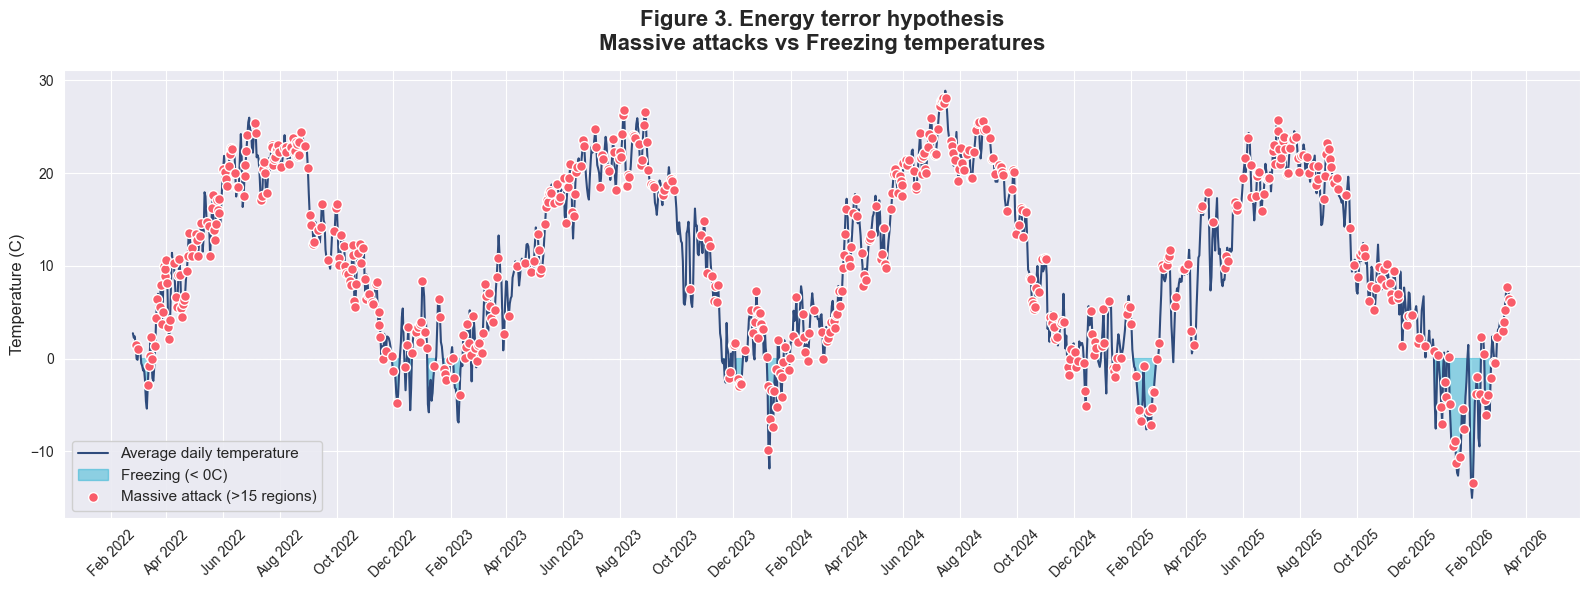

In [4]:
import matplotlib.dates as mdates
import pandas as pd
import matplotlib.pyplot as plt

df_m['datetime'] = pd.to_datetime(df_m['datetime_hour'])
df_daily = df_m.groupby(df_m['datetime'].dt.date).agg(
    avg_temp = ('hour_temp', 'mean'),
    max_alarms = ('n_regions_alarm', 'max')).reset_index()
df_daily['datetime'] = pd.to_datetime(df_daily['datetime'])
fig, ax1 = plt.subplots(figsize = (16, 6))

ax1.plot(df_daily['datetime'], df_daily['avg_temp'], color = PAL['blue'],
         linewidth = 1.5, label = 'Average daily temperature', zorder = 2)

ax1.axhline(0, color = 'white', linestyle = '--', linewidth = 1, alpha = 0.5, zorder = 1)
ax1.fill_between(df_daily['datetime'], df_daily['avg_temp'], 0, where = (df_daily['avg_temp'] < 0), color='#00a8cc',
                 alpha = 0.4, label = 'Freezing (< 0C)', zorder = 1)
mass_attacks = df_daily[df_daily['max_alarms'] > 15]
ax1.scatter(mass_attacks['datetime'], mass_attacks['avg_temp'], color = PAL['coral'], edgecolor='white', s = 50,
            label = 'Massive attack (>15 regions)', zorder=3)
ax1.set_ylabel('Temperature (C)', fontsize = 12)
ax1.set_title('Figure 3. Energy terror hypothesis\nMassive attacks vs Freezing temperatures',
              fontsize = 16, fontweight = 'bold', pad = 15)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval = 2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation = 45)
ax1.legend(loc = 'lower left', fontsize = 11, framealpha = 0.9, scatterpoints = 1)
plt.tight_layout()
plt.savefig('plots/merged/3_energy_terror.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## Conclusion (Figure 3)
Figure 3 visualizes the relationship between daily average temperatures and the occurrence of massive air alarms (>15 regions). The hypothesis is rejected. The data does not support the claim that freezing temperatures serve as a deliberate trigger for massive attacks.
*  While the winter of 2022 - 2023 saw targeted attacks on the energy grid, the scatter plot reveals that massive alarms occur with high frequency year-round, regardless of freezing temperatures. This indicates that current metric ('alarms in >15 regions') captures all nationwide alerts (such as MiG-31K takeoffs), which happen independently of weather conditions.
*  The dense clusters of red points during the hot summer of 2024 highlight that temperature alone is an insufficient predictor for massive alarms. To model 'energy terror', the dataset would require additional features that differentiate weapon types (e.g., Shaheds vs cruise missiles) rather than relying on the number of affected regions.
* Periodicity: The chart illustrates waves of attacks. This highlights the need for the model to account not only for current weather conditions but also whether an attack occurred the previous day (time dependence). The periodicity of attack waves becomes more pronounced with the addition of 2025 - 2026 data, reinforcing the importance of temporal features over meteorological ones.

## 4. NEWS ESCALATION

## Hypothesis 4
We hypothesize that the intensity of war-related terminology (specifically the word ʼattackʼ) in ISW reports serves as a leading indicator of military escalation, meaning that a highly aggressive news cycle yesterday directly correlates with an increased probability of air alarms today.

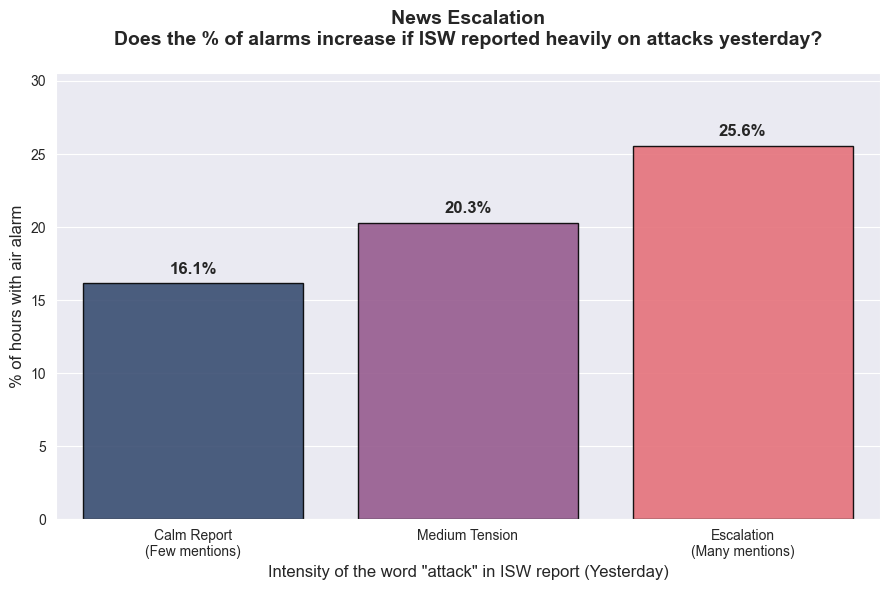

In [5]:
import warnings
warnings.filterwarnings('ignore', category = FutureWarning)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("darkgrid")
df_m['isw_tension'] = pd.qcut(df_m['attack_mentions'].rank(method='first'), q = 3,
                              labels = ['Calm Report\n(Few mentions)',
                                      'Medium Tension',
                                      'Escalation\n(Many mentions)'])
escalation_df = df_m.groupby('isw_tension', observed=False)['alarm'].mean() * 100
plt.figure(figsize = (9, 6))
colors = ['#2f4b7c', '#a05195', '#f95d6a']
ax = sns.barplot( x = escalation_df.index, y = escalation_df.values, hue = escalation_df.index,
    palette = colors, edgecolor = 'black', alpha = 0.9, legend = False )

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha ='center', va ='bottom', xytext = (0, 5), textcoords = 'offset points',
                fontsize = 12, fontweight = 'bold')
plt.title('News Escalation\nDoes the % of alarms increase if ISW reported heavily on attacks yesterday?',
          fontsize = 14, fontweight ='bold', pad =20)
plt.ylabel('% of hours with air alarm', fontsize=12)
plt.xlabel('Intensity of the word "attack" in ISW report (Yesterday)', fontsize=12)
plt.ylim(0, max(escalation_df.values) + 5)

plt.tight_layout()
plt.savefig('plots/merged/4_ISW_news_escalation.png', dpi=150)
plt.show()

## Conclusion (Figure 4)
The chart shows a step‑like increase - the more aggressive yesterday’s report was, the higher the chance of hearing an alarm today.
The difference between 16.1% and 25.6% may seem small. But compared to a calm day, the probability of an alarm after an escalatory report rises by 59% (25.6/16.1 = 1.59).
The ISW text itself does not launch missiles. But the chart proves that NLP metrics really work as an escalation thermometer. ISW analysts record actual troop movements, aggressive rhetoric, or preparations for attacks - and those words appear in the report. In this sense, attack_mentions serve as a leading indicator.

## 5. WIND ROSE AND ALARMS

## Hypothesis 5
We hypothesize that wind direction plays a tactical role in the timing of aerial attacks, particularly for slower-moving drones that are sensitive to aerodynamic conditions. We expect a higher frequency of alarms when the wind blows from the North-East or East (originating from russian territories), as the adversary might utilize tailwinds to increase the speed, range, and fuel efficiency of incoming projectiles.

Average alarm rate: 20.7%
Chance of alarms NE: 24.1%
Difference with average: +3.5%


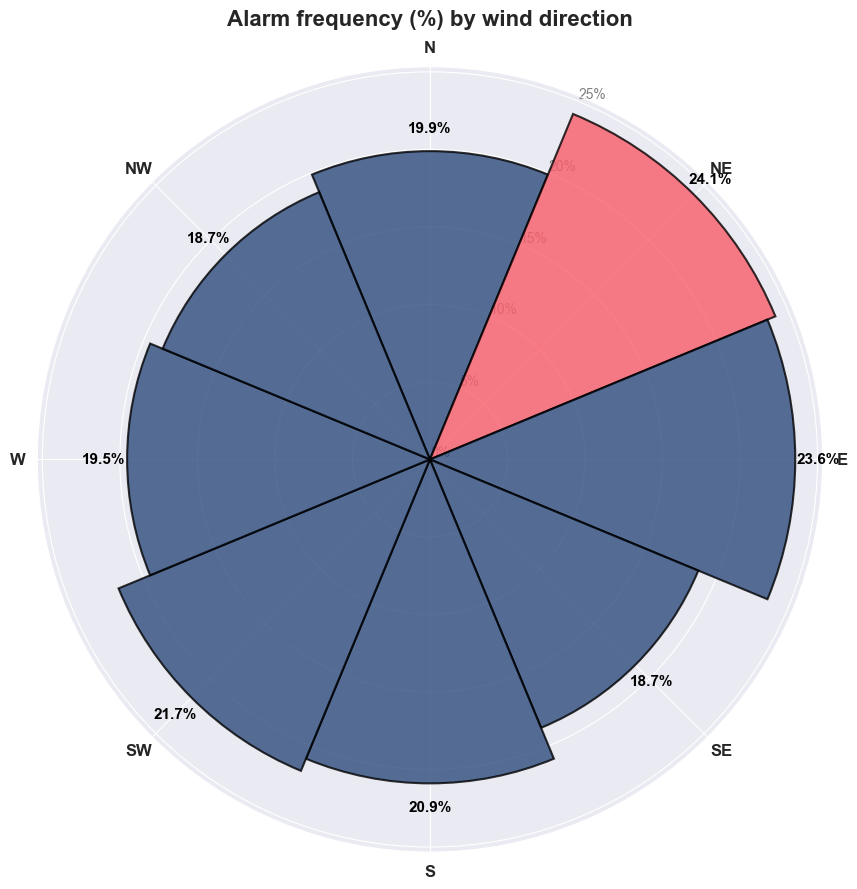

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_wind = df_m.dropna(subset = ['hour_winddir', 'alarm']).copy()

bins = [0, 22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5, 360]
labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW', 'N_2']

df_wind['wind_dir_cat'] = pd.cut(df_wind['hour_winddir'], bins = bins, labels = labels, right = False)
df_wind['wind_dir_cat'] = df_wind['wind_dir_cat'].astype(str).replace({'N_2': 'N'})
wind_stats = df_wind.groupby('wind_dir_cat')['alarm'].mean() * 100

avg_alarm_rate = df_wind['alarm'].mean() * 100
print(f"Average alarm rate: {avg_alarm_rate:.1f}%")
wind_frequency = df_wind['wind_dir_cat'].value_counts(normalize = True) * 100
ne_risk = wind_stats.get('NE', 0)
diff = ne_risk - avg_alarm_rate
print(f"Chance of alarms NE: {ne_risk:.1f}%")
print(f"Difference with average: {diff:+.1f}%")

directions = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
values = [wind_stats.get(d, 0) for d in directions]
angles = np.linspace(0, 2 * np.pi, len(directions), endpoint = False)
width = 2 * np.pi / len(directions)

fig, ax = plt.subplots(figsize = (9, 9), subplot_kw = {'polar': True})

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

colors = ['#f95d6a' if val == max(values) else '#2f4b7c' for val in values]
bars = ax.bar(angles, values, width = width, color = colors, alpha = 0.8, edgecolor = 'black', linewidth = 1.5)

ax.set_xticks(angles)
ax.set_xticklabels(directions, fontsize = 12, fontweight = 'bold')
ax.set_yticks(np.arange(0, max(values) + 5, 5))
ax.set_yticklabels([f'{int(y)}%' for y in ax.get_yticks()], color = 'grey', fontsize = 10)
ax.set_rlabel_position(22.5)
for bar, angle, val in zip(bars, angles, values):
    ax.text(angle, val + 1.5, f'{val:.1f}%', ha ='center', va = 'center',
            fontsize = 11, fontweight = 'bold', color = 'black')

plt.title('Alarm frequency (%) by wind direction',
          fontsize = 16, fontweight ='bold', pad = 30)

plt.tight_layout()
plt.savefig('plots/merged/Wind_Rose_Alarms.png', dpi = 150)
plt.show()

## Conclusion (Figure 5)
The analysis shows a moderate correlation between wind direction and the frequency of air alerts. The average alert probability is about 20.7%, but during a Northeastern wind, this figure increases to 24.1%, a rise of 3.4% compared to the average.

This somewhat supports the idea that weather conditions, particularly downwind winds from Russia, could serve as an additional tactical factor when planning Shahed drone attacks to conserve fuel. However, since the deviation from the average is not highly significant, it suggests that wind isn't a decisive factor. Attacks are carried out under a wide range of weather conditions, and wind likely plays only a minor role.

## 6. COLD NIGHTS ALARMS

## Hypothesis 6
We hypothesize that freezing nights represent the most dangerous operational window for the adversary, as the darkness conceals low-flying drones while the low temperatures maximize the potential damage to the civilian energy infrastructure.

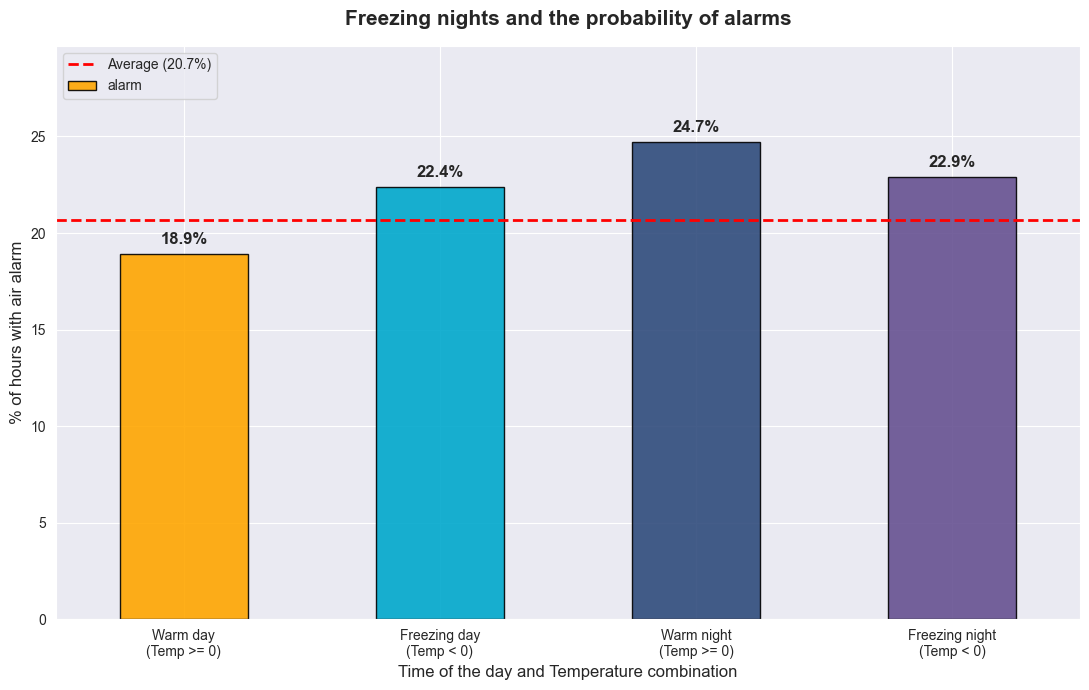

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
df_m['night_cold_combo'] = 'Something'
df_m.loc[(df_m['is_night'] == 0) & (df_m['hour_temp'] >= 0), 'night_cold_combo'] = 'Warm day\n(Temp >= 0)'
df_m.loc[(df_m['is_night'] == 0) & (df_m['hour_temp'] < 0), 'night_cold_combo'] = 'Freezing day\n(Temp < 0)'
df_m.loc[(df_m['is_night'] == 1) & (df_m['hour_temp'] >= 0), 'night_cold_combo'] = 'Warm night\n(Temp >= 0)'
df_m.loc[(df_m['is_night'] == 1) & (df_m['hour_temp'] < 0), 'night_cold_combo'] = 'Freezing night\n(Temp < 0)'

night_cold_percentage = df_m.groupby('night_cold_combo')['alarm'].mean() * 100
order = ['Warm day\n(Temp >= 0)', 'Freezing day\n(Temp < 0)', 'Warm night\n(Temp >= 0)', 'Freezing night\n(Temp < 0)']
night_cold_stats = night_cold_percentage.reindex(order)

plt.figure(figsize = (11, 7))
my_palette = ['#ffa600', '#00a8cc', '#2f4b7c', '#665191']

ax = night_cold_stats.plot(kind = 'bar', color = my_palette, edgecolor = 'black', alpha = 0.9)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va ='bottom', xytext = (0, 5), textcoords = 'offset points', fontsize = 12, fontweight='bold')

plt.title('Freezing nights and the probability of alarms', fontsize = 15, fontweight = 'bold', pad = 15)
plt.ylabel('% of hours with air alarm', fontsize = 12)
plt.xlabel('Time of the day and Temperature combination', fontsize = 12)
plt.xticks(rotation = 0)
plt.ylim(0, max(night_cold_stats) + 5)

avg_alarm_rate = 20.7
plt.axhline(y = avg_alarm_rate, color = 'red', linestyle = '--', linewidth = 2, label = f'Average ({avg_alarm_rate}%)')
plt.legend(fontsize = 10, loc = 'upper left')
plt.tight_layout()
plt.savefig('plots/merged/6.Freezing_Nights.png', dpi = 150)
plt.show()

## Conclusion (Figure 6)
Visualizing the combined factors of time of day and temperature against the average alert rate 20.7%, marked by the red line allows for several observations.
* The data confirm that both nighttime scenarios carry higher risk than the average. The highest rate is recorded during warm nights 24.7%, which is 4 percentage points above the baseline. This supports the pattern of enemy forces exploiting darkness to hinder the work of visual air defense posts.
* Contrary to expectations, freezing nights does not emerge as the primary trigger for attacks. Although the alert rate during freezing conditions 22.9% remains above average, it is 1.8 percentage points lower than during warm nights.

## 7. Precipitation

## Hypothesis 7
We hypothesize that rain or snow acts as a mechanical deterrent for aerial attacks, significantly lowering the alarm rate because heavy moisture degrades the aerodynamics and navigation sensors of lightweight drones.

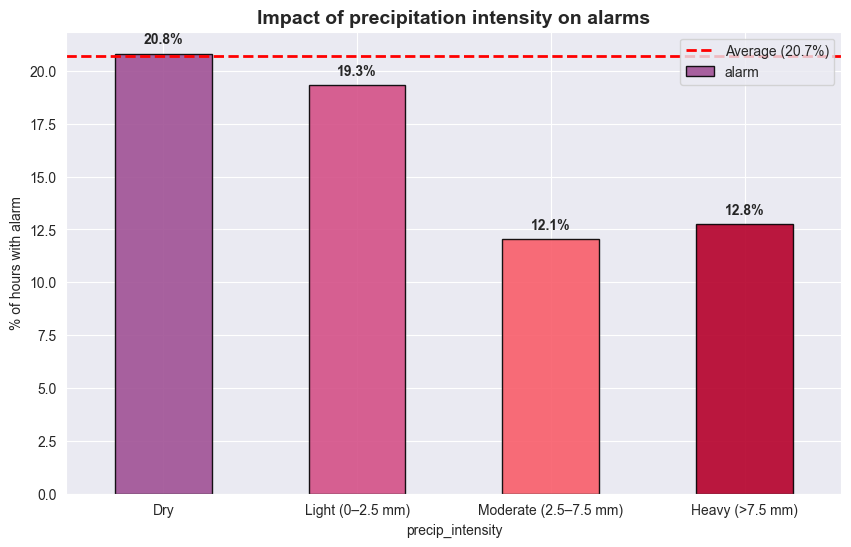

In [17]:
df_m['precip_intensity'] = 'Dry'
df_m.loc[(df_m['hour_precip'] > 0) & (df_m['hour_precip'] <= 2.5), 'precip_intensity'] = 'Light (0–2.5 mm)'
df_m.loc[(df_m['hour_precip'] > 2.5) & (df_m['hour_precip'] <= 7.5), 'precip_intensity'] = 'Moderate (2.5–7.5 mm)'
df_m.loc[df_m['hour_precip'] > 7.5, 'precip_intensity'] = 'Heavy (>7.5 mm)'

precip = df_m.groupby('precip_intensity')['alarm'].mean() * 100
order = ['Dry', 'Light (0–2.5 mm)', 'Moderate (2.5–7.5 mm)', 'Heavy (>7.5 mm)']
precip = precip.reindex(order)
plt.figure(figsize = (10, 6))
colors = ['#a05195', '#d45087', '#f95d6a', '#b5002a']
ax = precip.plot(kind = 'bar', color = colors, edgecolor = 'black', alpha = 0.9)
avg_alarm_rate = 20.7
plt.axhline(y = avg_alarm_rate, color = 'red', linestyle ='--', linewidth = 2, label = f'Average ({avg_alarm_rate}%)')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'bottom', xytext = (0, 5), textcoords = 'offset points', fontweight = 'bold')
plt.title('Impact of precipitation intensity on alarms', fontsize = 14, fontweight = 'bold')
plt.ylabel('% of hours with alarm')
plt.legend()
plt.xticks(rotation = 0)
plt.show()

## Conclusion (Figure 7)
The distribution by precipitation intensity partially supports the hypothesis.
Light rain or snow (0 - 2.5 mm) shows no deterrent effect, with an alarm rate of 19.3% - identical to dry conditions 20.8%. A meaningful drop occurs only at moderate precipitation (2.5 - 7.5 mm), where the alarm rate falls to 12.1%, 8 percentage points below the average. Notably, heavy precipitation (>7.5 mm) does not reduce the rate further. It slightly rebounds to 12.8% suggesting that beyond a certain intensity threshold, additional rainfall has no additional deterrent effect. This indicates that the critical factor is crossing the moderate precipitation boundary, not the absolute volume of rainfall.